# E-Commerce Sales Prediction

## Machine Learning Capstone Project — Regression Track

### Problem Statement
The objective of this project is to develop and compare machine learning regression models for predicting the number of units sold in an e-commerce environment.

### Target Variable
**Units_Sold**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/Ecommerce_Sales_Prediction_Dataset.csv")

df.head()

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01-01-2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02-01-2023,Toys,569.48,3.60,Premium,6807.56,16
2,03-01-2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04-01-2023,Toys,923.27,0.61,Premium,9422.75,29
4,05-01-2023,Toys,710.17,47.83,Premium,1756.83,17


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 7)


In [4]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Date', 'Product_Category', 'Price', 'Discount', 'Customer_Segment', 'Marketing_Spend', 'Units_Sold']


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
Date                 object
Product_Category     object
Price               float64
Discount            float64
Customer_Segment     object
Marketing_Spend     float64
Units_Sold            int64
dtype: object


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
dtype: int64


In [7]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [8]:
df.describe()

,Price,Discount,Marketing_Spend,Units_Sold
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,505.241920,24.919750,4912.830240,29.631000
std,289.791248,14.439951,2840.602656,7.267989
min,14.590000,0.010000,100.300000,5.000000
25%,243.342500,12.995000,2413.020000,24.000000
50%,509.310000,24.965000,4837.245000,30.000000
75%,747.592500,37.562500,7319.675000,34.000000
max,999.420000,49.920000,9995.620000,57.000000


In [9]:
print("Product Categories:")
print(df["Product_Category"].value_counts())

print("\nCustomer Segments:")
print(df["Customer_Segment"].value_counts())

Product Categories:
Product_Category
Electronics    210
Sports         206
Toys           204
Home Decor     190
Fashion        190
Name: count, dtype: int64

Customer Segments:
Customer_Segment
Regular       345
Occasional    339
Premium       316
Name: count, dtype: int64


In [10]:
print("Target Variable - Units Sold:")
print(df["Units_Sold"].describe())

Target Variable - Units Sold:
count    1000.000000
mean       29.631000
std         7.267989
min         5.000000
25%        24.000000
50%        30.000000
75%        34.000000
max        57.000000
Name: Units_Sold, dtype: float64


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distributions,
patterns and relationships present in the dataset before model training.

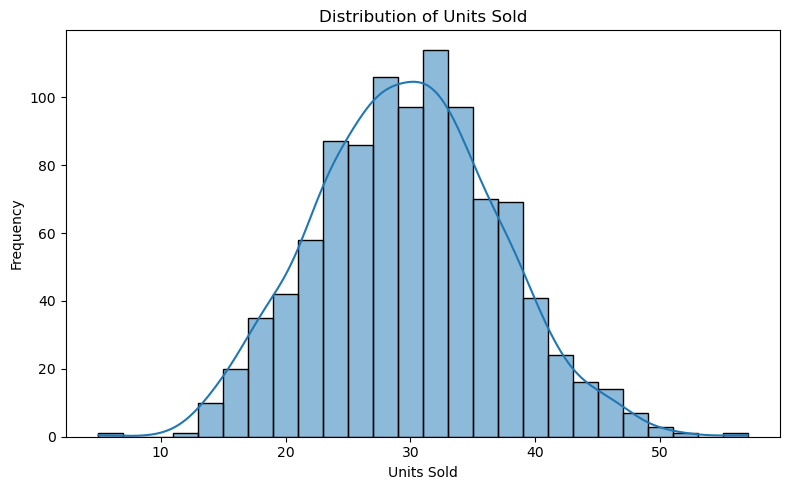

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Units_Sold"], kde=True)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The distribution of Units_Sold is approximately bell-shaped, with most sales values concentrated around 25 to 35 units. The highest frequency occurs near 30 units sold. Very low and very high sales values occur less frequently compared to values near the center.

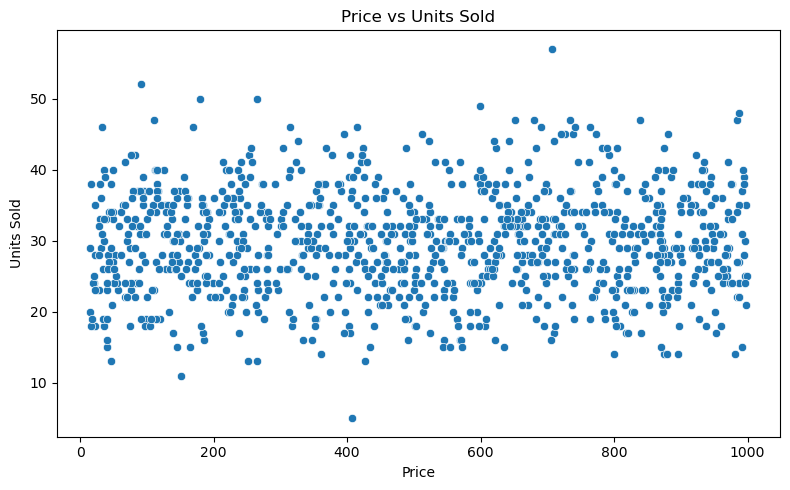

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Price", y="Units_Sold")

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

The points are widely scattered across the full price range, with no clear upward or downward pattern. This suggests that Price does not show a strong linear relationship with Units_Sold in this dataset.

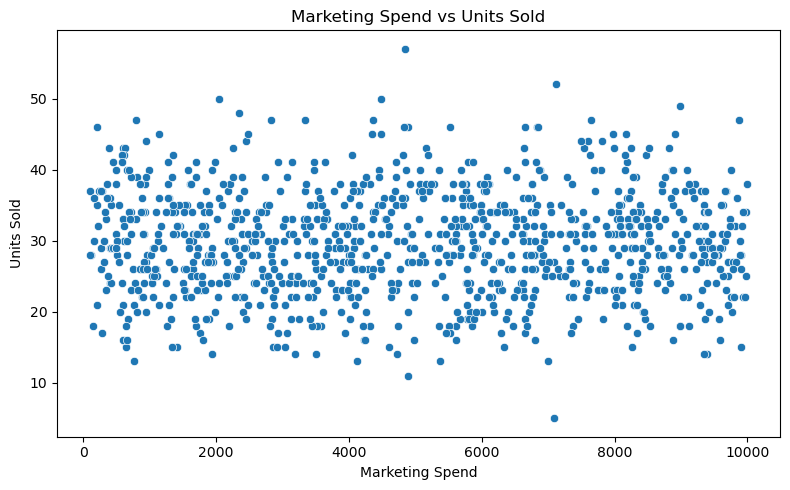

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Marketing_Spend", y="Units_Sold")

plt.title("Marketing Spend vs Units Sold")
plt.xlabel("Marketing Spend")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

The scatter plot shows that Units_Sold remains widely distributed across different levels of Marketing_Spend. There is no clear increasing or decreasing pattern, suggesting that Marketing_Spend does not have a strong linear relationship with Units_Sold.

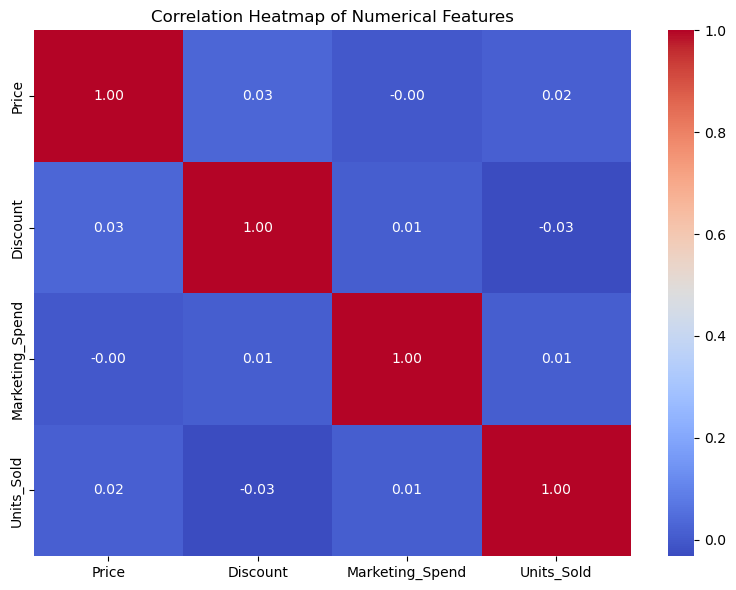

In [14]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The correlation heatmap shows that Price, Discount, and Marketing_Spend have correlation values very close to zero with Units_Sold. Therefore, the numerical features do not show a strong linear relationship with the target variable. This suggests that the relationship between the predictors and sales may be weak, nonlinear, or influenced by other features.

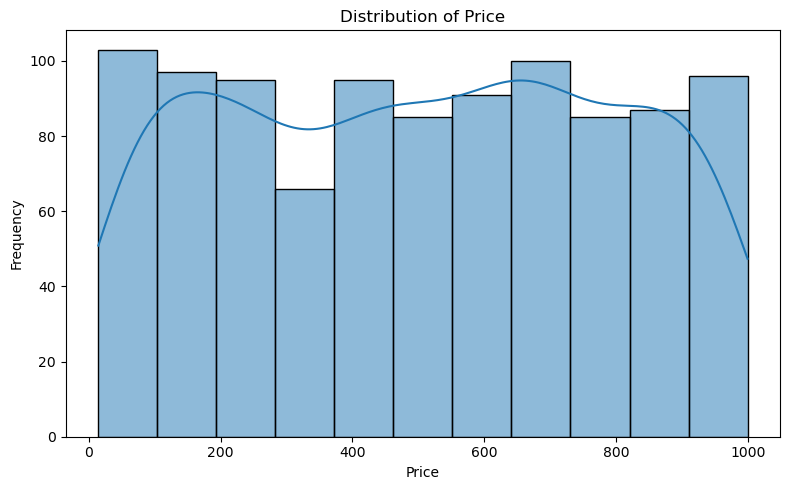

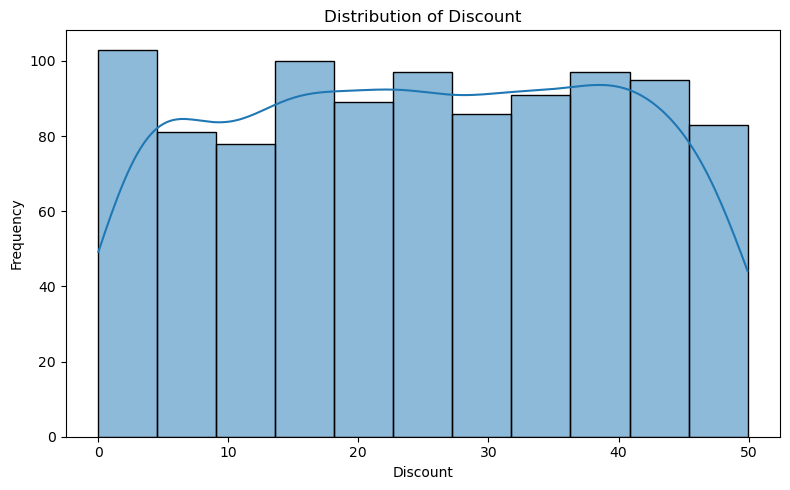

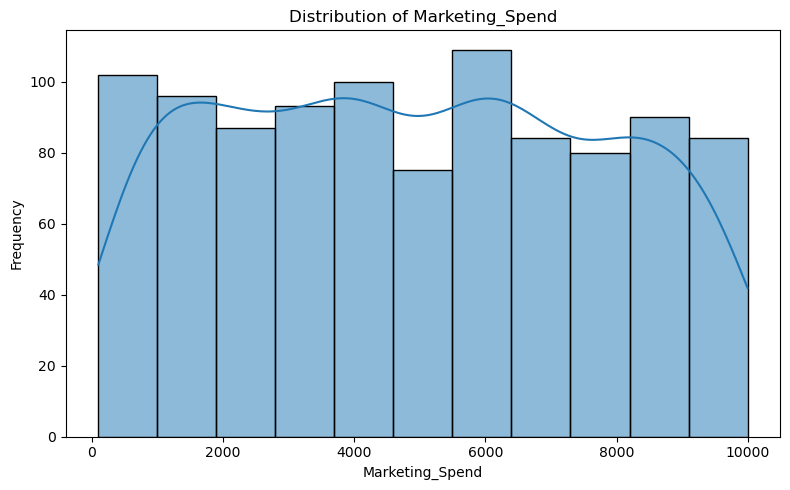

In [15]:
numerical_features = ["Price", "Discount", "Marketing_Spend"]

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

The distributions of Price, Discount, and Marketing_Spend are spread across their respective ranges without a strong concentration around a single value. Compared with Units_Sold, these numerical input features appear more evenly distributed across their ranges.

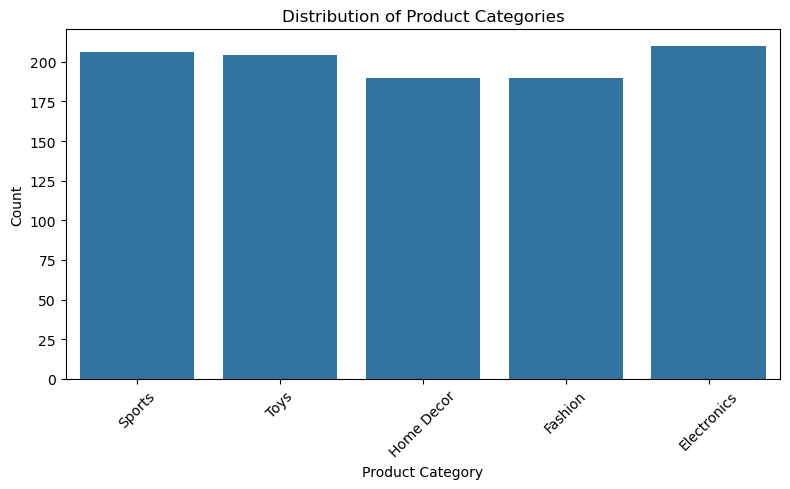

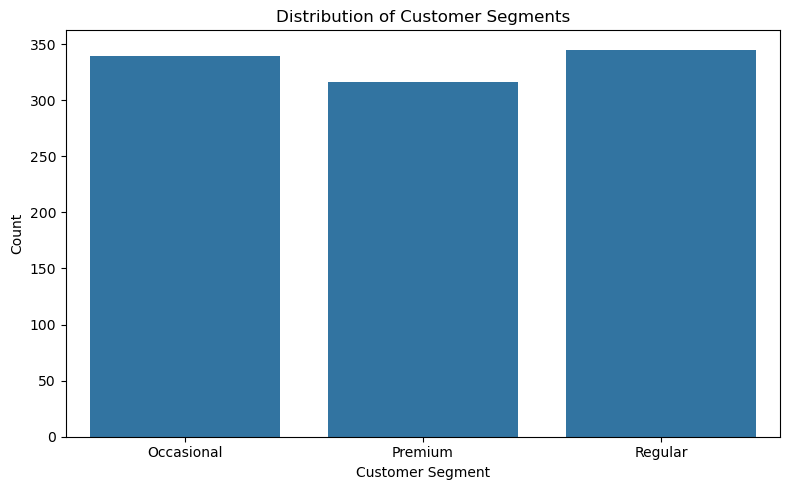

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Product_Category")

plt.title("Distribution of Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Customer_Segment")

plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


The Product_Category observations are fairly evenly distributed across the five categories. Customer_Segment is also reasonably balanced across Occasional, Premium, and Regular customers. Therefore, there is no major dominance by a single category in these features.

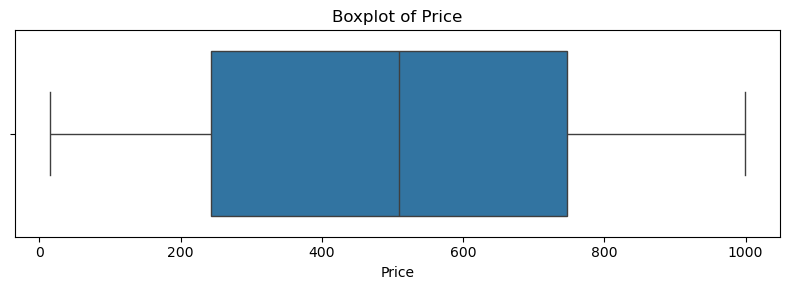

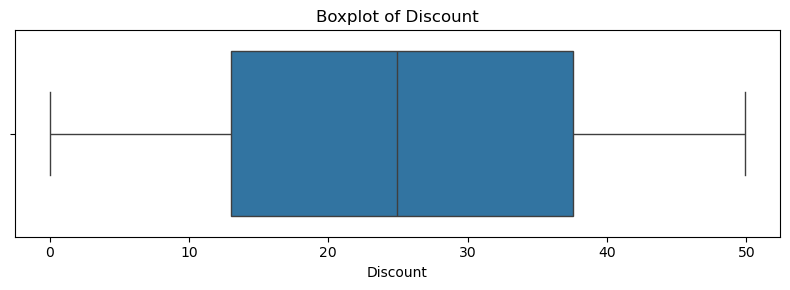

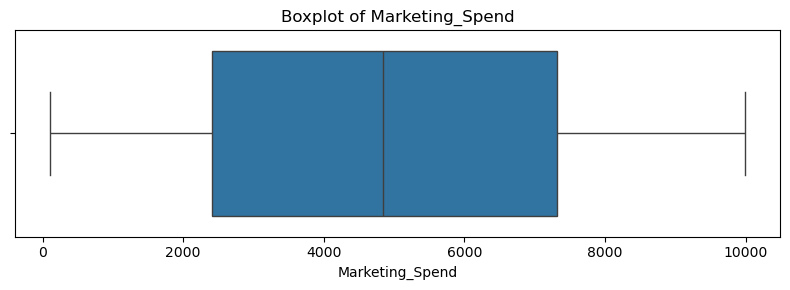

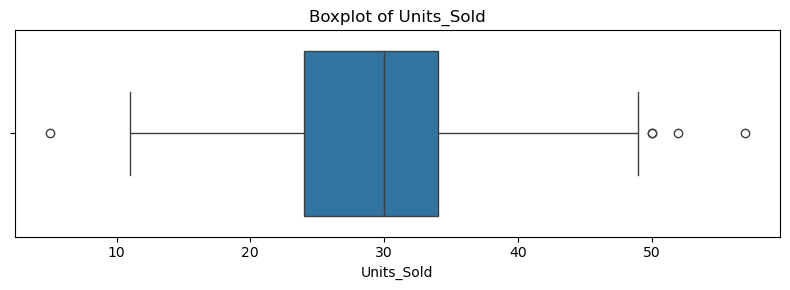

In [17]:
numerical_features = ["Price", "Discount", "Marketing_Spend", "Units_Sold"]

for feature in numerical_features:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

The boxplots show no apparent outliers in Price, Discount, or Marketing_Spend. A small number of potential outliers are present in Units_Sold at the lower and upper ends. Since these values are plausible sales observations and there is no evidence that they are erroneous, they are retained in the dataset.

In [18]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

print(df["Date"].dtype)
print(df["Date"].head())

datetime64[ns]
0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: Date, dtype: datetime64[ns]


In [19]:
# Feature Engineering from Date

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df.head()

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold,Year,Month,Day,DayOfWeek
0,2023-01-01,Sports,932.80,35.82,Occasional,6780.38,32,2023,1,1,6
1,2023-01-02,Toys,569.48,3.60,Premium,6807.56,16,2023,1,2,0
2,2023-01-03,Home Decor,699.68,3.56,Premium,3793.91,27,2023,1,3,1
3,2023-01-04,Toys,923.27,0.61,Premium,9422.75,29,2023,1,4,2
4,2023-01-05,Toys,710.17,47.83,Premium,1756.83,17,2023,1,5,3


In [20]:
print("Unique Years:", df["Year"].unique())
print("Unique Months:", df["Month"].unique())
print("Unique Days:", df["Day"].unique())
print("Unique Days of Week:", df["DayOfWeek"].unique())

Unique Years: [2023 2024 2025]
Unique Months: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Unique Days: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
Unique Days of Week: [6 0 1 2 3 4 5]


In [21]:
# Separate input features and target

X = df.drop(columns=["Units_Sold", "Date"])
y = df["Units_Sold"]

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=["Product_Category", "Customer_Segment"],
    drop_first=True,
    dtype=int
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X.head()

X Shape: (1000, 13)
y Shape: (1000,)


,Price,Discount,Marketing_Spend,Year,Month,Day,DayOfWeek,Product_Category_Fashion,Product_Category_Home Decor,Product_Category_Sports,Product_Category_Toys,Customer_Segment_Premium,Customer_Segment_Regular
0,932.80,35.82,6780.38,2023,1,1,6,0,0,1,0,0,0
1,569.48,3.60,6807.56,2023,1,2,0,0,0,0,1,1,0
2,699.68,3.56,3793.91,2023,1,3,1,0,1,0,0,1,0
3,923.27,0.61,9422.75,2023,1,4,2,0,0,0,1,1,0
4,710.17,47.83,1756.83,2023,1,5,3,0,0,0,1,1,0


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 13)
X_test: (200, 13)
y_train: (800,)
y_test: (200,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nMean of scaled training features:")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nStandard deviation of scaled training features:")
print(np.round(X_train_scaled.std(axis=0), 2))

Training data shape: (800, 13)
Testing data shape: (200, 13)

Mean of scaled training features:
[ 0.  0.  0. -0.  0.  0. -0.  0.  0.  0. -0. -0.  0.]

Standard deviation of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Regression Models

### 1. Linear Regression
Linear Regression is used as a baseline model to examine the linear relationship between the input features and Units_Sold.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression Results")
print("R2 Score:", round(linear_r2, 4))
print("RMSE:", round(linear_rmse, 4))
print("MAE:", round(linear_mae, 4))

Linear Regression Results
R2 Score: -0.0438
RMSE: 7.5134
MAE: 5.9628


### Observation
The Linear Regression model produced an R² score of -0.0438, RMSE of 7.5134, and MAE of 5.9628. The negative R² indicates that a simple linear model does not capture the relationship between the available features and Units_Sold effectively. Therefore, more flexible regression models should be evaluated.

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_mae = mean_absolute_error(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("R2 Score:", round(poly_r2, 4))
print("RMSE:", round(poly_rmse, 4))
print("MAE:", round(poly_mae, 4))

Polynomial Regression Results
R2 Score: -0.1166
RMSE: 7.771
MAE: 6.1912


In [26]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("R2 Score:", round(ridge_r2, 4))
print("RMSE:", round(ridge_rmse, 4))
print("MAE:", round(ridge_mae, 4))

Ridge Regression Results
R2 Score: -0.0437
RMSE: 7.5131
MAE: 5.9626


In [27]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("R2 Score:", round(lasso_r2, 4))
print("RMSE:", round(lasso_rmse, 4))
print("MAE:", round(lasso_mae, 4))

Lasso Regression Results
R2 Score: -0.0103
RMSE: 7.3918
MAE: 5.9008


In [28]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

elastic_r2 = r2_score(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)

print("Elastic Net Regression Results")
print("R2 Score:", round(elastic_r2, 4))
print("RMSE:", round(elastic_rmse, 4))
print("MAE:", round(elastic_mae, 4))

Elastic Net Regression Results
R2 Score: -0.0103
RMSE: 7.3918
MAE: 5.9008


In [29]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree Regression Results")
print("R2 Score:", round(dt_r2, 4))
print("RMSE:", round(dt_rmse, 4))
print("MAE:", round(dt_mae, 4))

Decision Tree Regression Results
R2 Score: -1.1052
RMSE: 10.6703
MAE: 8.415


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("R2 Score:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

Random Forest Regression Results
R2 Score: -0.1066
RMSE: 7.7363
MAE: 6.0911


In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("R2 Score:", round(gb_r2, 4))
print("RMSE:", round(gb_rmse, 4))
print("MAE:", round(gb_mae, 4))

Gradient Boosting Regression Results
R2 Score: -0.0535
RMSE: 7.5485
MAE: 6.0057


In [32]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf")
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("SVR Results")
print("R2 Score:", round(svr_r2, 4))
print("RMSE:", round(svr_rmse, 4))
print("MAE:", round(svr_mae, 4))

SVR Results
R2 Score: -0.0535
RMSE: 7.5482
MAE: 5.9513


In [33]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("KNN Regression Results")
print("R2 Score:", round(knn_r2, 4))
print("RMSE:", round(knn_rmse, 4))
print("MAE:", round(knn_mae, 4))

KNN Regression Results
R2 Score: -0.2242
RMSE: 8.1369
MAE: 6.314


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "KNN"
    ],
    
    "R2 Score": [
        linear_r2,
        poly_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2,
        knn_r2
    ],
    
    "RMSE": [
        linear_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        svr_rmse,
        knn_rmse
    ],
    
    "MAE": [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae,
        knn_mae
    ]
})

results.round(4)

,Model,R2 Score,RMSE,MAE
0,Linear Regression,-0.0438,7.5134,5.9628
1,Polynomial Regression,-0.1166,7.7710,6.1912
2,Ridge Regression,-0.0437,7.5131,5.9626
3,Lasso Regression,-0.0103,7.3918,5.9008
4,Elastic Net,-0.0103,7.3918,5.9008
5,Decision Tree,-1.1052,10.6703,8.4150
6,Random Forest,-0.1066,7.7363,6.0910
7,Gradient Boosting,-0.0535,7.5485,6.0057
8,SVR,-0.0535,7.5482,5.9513
9,KNN,-0.2242,8.1369,6.3140


### Model Comparison Observation

The regression models show generally poor predictive performance, with all R² scores being negative. Lasso Regression and Elastic Net give the lowest RMSE (7.3918) and MAE (5.9008) among the tested models. Decision Tree performs considerably worse than the other models. Overall, the available features do not appear to provide strong predictive information for Units_Sold.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

lasso_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_grid,
    cv=5,
    scoring="r2"
)

lasso_search.fit(X_train_scaled, y_train)

best_lasso = lasso_search.best_estimator_
tuned_lasso_pred = best_lasso.predict(X_test_scaled)

tuned_lasso_r2 = r2_score(y_test, tuned_lasso_pred)
tuned_lasso_rmse = np.sqrt(mean_squared_error(y_test, tuned_lasso_pred))
tuned_lasso_mae = mean_absolute_error(y_test, tuned_lasso_pred)

print("Best Parameters:", lasso_search.best_params_)
print("Tuned Lasso R2:", round(tuned_lasso_r2, 4))
print("Tuned Lasso RMSE:", round(tuned_lasso_rmse, 4))
print("Tuned Lasso MAE:", round(tuned_lasso_mae, 4))

Best Parameters: {'alpha': 1}
Tuned Lasso R2: -0.0103
Tuned Lasso RMSE: 7.3918
Tuned Lasso MAE: 5.9008


In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

elastic_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_grid,
    cv=5,
    scoring="r2"
)

elastic_search.fit(X_train_scaled, y_train)

best_elastic = elastic_search.best_estimator_
tuned_elastic_pred = best_elastic.predict(X_test_scaled)

tuned_elastic_r2 = r2_score(y_test, tuned_elastic_pred)
tuned_elastic_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_elastic_pred)
)
tuned_elastic_mae = mean_absolute_error(
    y_test, tuned_elastic_pred
)

print("Best Parameters:", elastic_search.best_params_)
print("Tuned Elastic Net R2:", round(tuned_elastic_r2, 4))
print("Tuned Elastic Net RMSE:", round(tuned_elastic_rmse, 4))
print("Tuned Elastic Net MAE:", round(tuned_elastic_mae, 4))

Best Parameters: {'alpha': 1, 'l1_ratio': 0.9}
Tuned Elastic Net R2: -0.0103
Tuned Elastic Net RMSE: 7.3918
Tuned Elastic Net MAE: 5.9008


In [37]:
from sklearn.model_selection import cross_val_score

lasso_cv = cross_val_score(
    best_lasso,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

elastic_cv = cross_val_score(
    best_elastic,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

cv_results = pd.DataFrame({
    "Model": ["Tuned Lasso", "Tuned Elastic Net"],
    "Mean CV R2": [lasso_cv.mean(), elastic_cv.mean()],
    "Std CV R2": [lasso_cv.std(), elastic_cv.std()]
})

print("Lasso 5-Fold R2:", np.round(lasso_cv, 4))
print("Elastic Net 5-Fold R2:", np.round(elastic_cv, 4))

cv_results.round(4)

Lasso 5-Fold R2: [-0.0108 -0.0205 -0.0001 -0.008  -0.0251]
Elastic Net 5-Fold R2: [-0.0108 -0.0205 -0.0001 -0.008  -0.0251]


,Model,Mean CV R2,Std CV R2
0,Tuned Lasso,-0.0129,0.009
1,Tuned Elastic Net,-0.0129,0.009


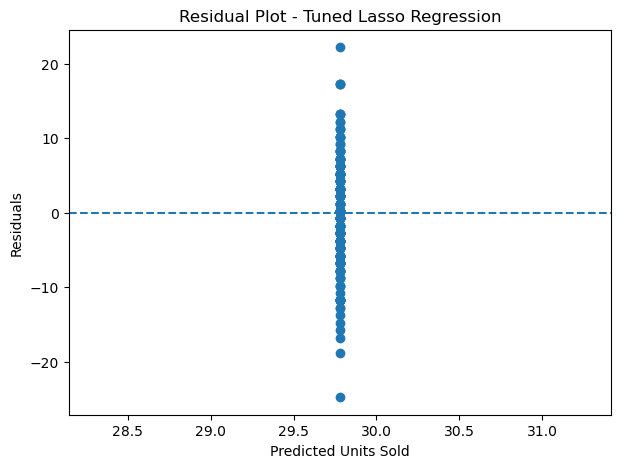

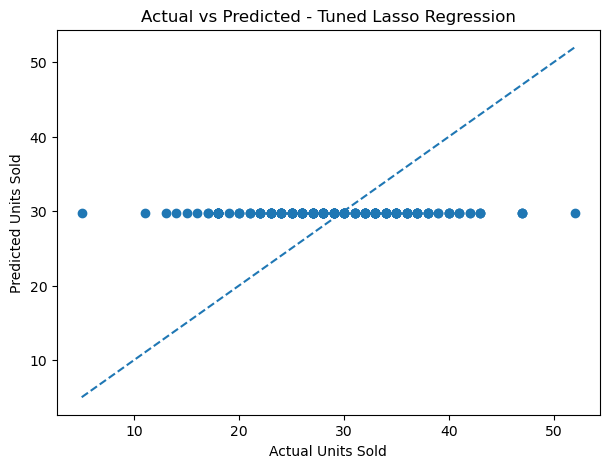

In [38]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - tuned_lasso_pred

# Residual Plot
plt.figure(figsize=(7, 5))
plt.scatter(tuned_lasso_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Units Sold")
plt.ylabel("Residuals")
plt.title("Residual Plot - Tuned Lasso Regression")
plt.show()

# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, tuned_lasso_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted - Tuned Lasso Regression")
plt.show()

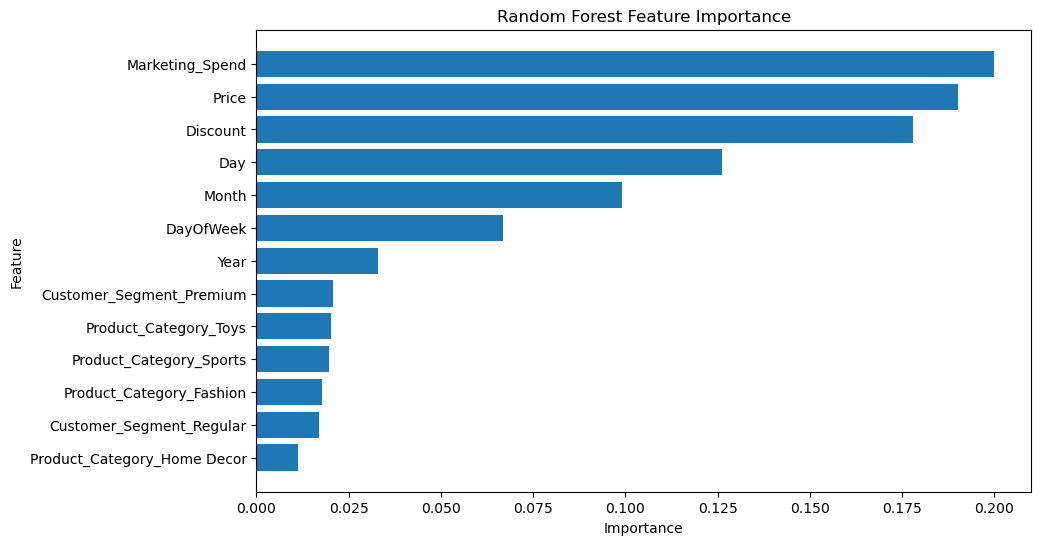

,Feature,Importance
2,Marketing_Spend,0.200053
0,Price,0.190120
1,Discount,0.178099
5,Day,0.126293
4,Month,0.098998
6,DayOfWeek,0.066748
3,Year,0.032923
11,Customer_Segment_Premium,0.020887
10,Product_Category_Toys,0.020091
9,Product_Category_Sports,0.019588


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

feature_importance